# Visualize a Single Run

In [2]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

## Get all of the numerical results, and print them

In [ ]:
pickled_obj = {}

with open('./allplots/sweep_height3/height60/results.pkl', 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]
u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
theta_at_dofs = pickled_obj["theta_at_dofs"]
theta_at_interior = theta_at_dofs[femsystem.interior_dofs]
n,coeffs = pickled_obj["n"],pickled_obj["coeffs"]
E_J,E_C,e_0 = pickled_obj["E_J"],pickled_obj["E_C"],pickled_obj["e0"]
parameters = pickled_obj["parameters"]
totalTime = pickled_obj["totalTime"]

integrated_volume = pickled_obj["integrated_volume"]
sidelenX, sidelenY, sidelenZ = parameters["sidelenX"], parameters["sidelenY"], parameters["sidelenZ"]
volume = 2 * sidelenX * sidelenY * sidelenZ
print(f"Volume Integration Error: {(integrated_volume - volume) / volume * 100:.4g}% | Integrated Volume: {integrated_volume} | Volume: {volume}")

print(f"EJ: {E_J:.4g}, EC: {E_C:.4g}, EJ/EC: {E_J/E_C:.4g} | Time: {int(totalTime // 60)}m {int(totalTime % 60)}s | Degrees of Freedom: {femsystem.dofs}")
print(f"Parameters:")
print(parameters)

Volume Integration Error: 4.234% | Integrated Volume: 12508.12109375 | Volume: 12000.0
EJ: 1.685, EC: 0.003055, EJ/EC: 551.5 | Time: 61m 37s | Degrees of Freedom: 955521
Parameters:
{'material': 0.0106, 'separation': 5.0, 'sidelenX': 10.0, 'sidelenY': 10.0, 'sidelenZ': 60.0, 'padding': 20.0, 'gridlenX': 55.0, 'gridlenY': 50.0, 'gridlenZ': 100.0, 'lc_large': 3.0, 'lc_small': 0.5}


In [4]:
# Time Breakdown

times = pickled_obj["times"]
mesh_gen_time,mesh_load_time,matrix_gen_time,objective_run_time,optimization_loop_time = times["mesh_gen"],times["mesh_load"],times["matrix_gen"],times["objective_run"],times["optimization_loop"]
print(f"Time Breakdown:")
print(f"  - Mesh Generation: {mesh_gen_time:.4g}s | {mesh_gen_time/totalTime*100:.4g}%")
print(f"  - Mesh Loading: {mesh_load_time:.4g}s | {mesh_load_time/totalTime*100:.4g}%")
print(f"  - Matrix Generation: {matrix_gen_time:.4g}s | {matrix_gen_time/totalTime*100:.4g}%")
print(f"  - Objective Run: {objective_run_time:.4g}s | {objective_run_time/totalTime*100:.4g}%")
print(f"  - Optimization Loop: {optimization_loop_time:.4g}s | {optimization_loop_time/totalTime*100:.4g}%")
print(f"  - Total: {totalTime:.4g}s")

Time Breakdown:
  - Mesh Generation: 28.13s | 0.7609%
  - Mesh Loading: 41.12s | 1.112%
  - Matrix Generation: 19.96s | 0.54%
  - Objective Run: 61.17s | 1.655%
  - Optimization Loop: 3510s | 94.94%
  - Total: 3697s


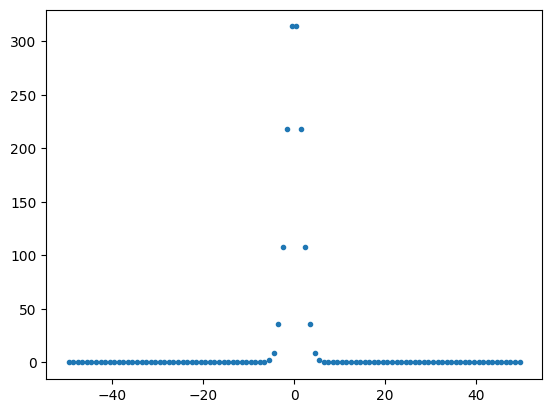

In [4]:
x = (n-1)/2 - jnp.arange(n)
plt.plot(x,coeffs,".")
# femsystem.plot_at_inteRior_2d(theta_at_dofs[femsystem.interior_dofs])
# femsystem.plot_at_interior_2d_in3d(u_odd_interior,plot_title="Odd Mode")
# femsystem.plot_at_interior_2d_in3d(u_even_interior,plot_title="Even Mode")

## Plot the Odd Mode, in Slices

V min to max: -0.021257035 0.021257035


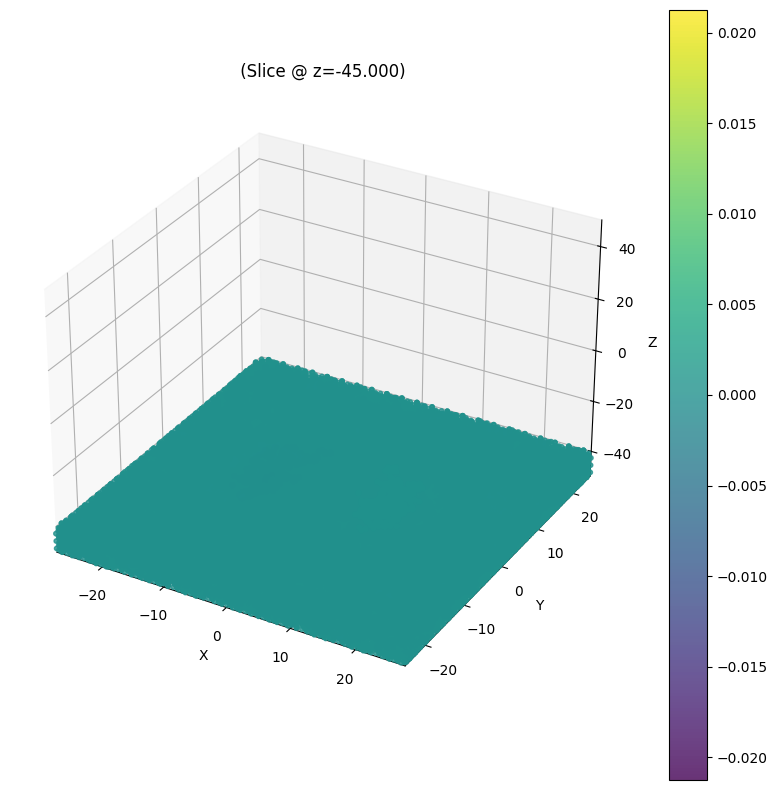

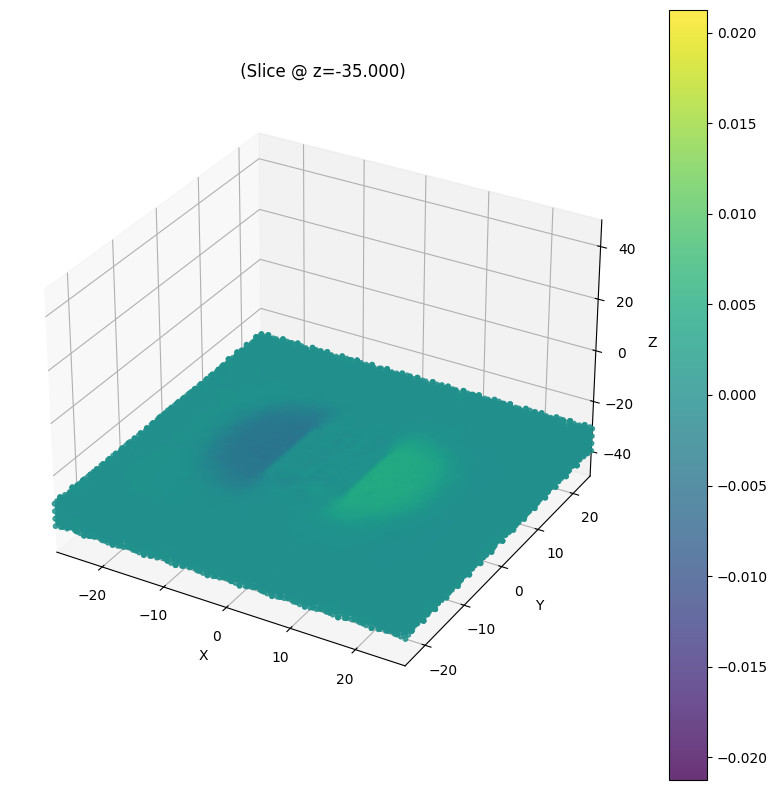

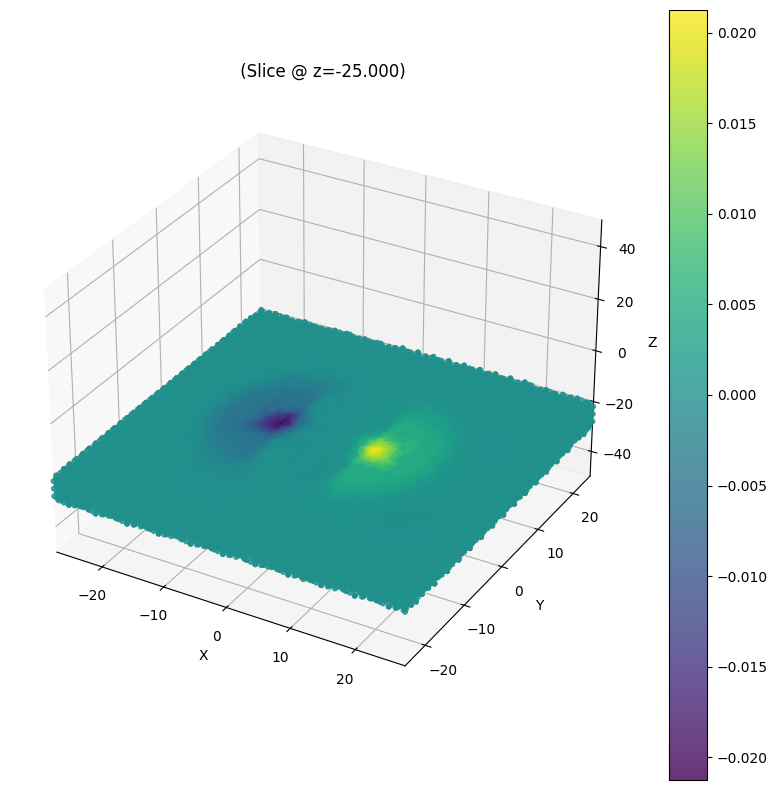

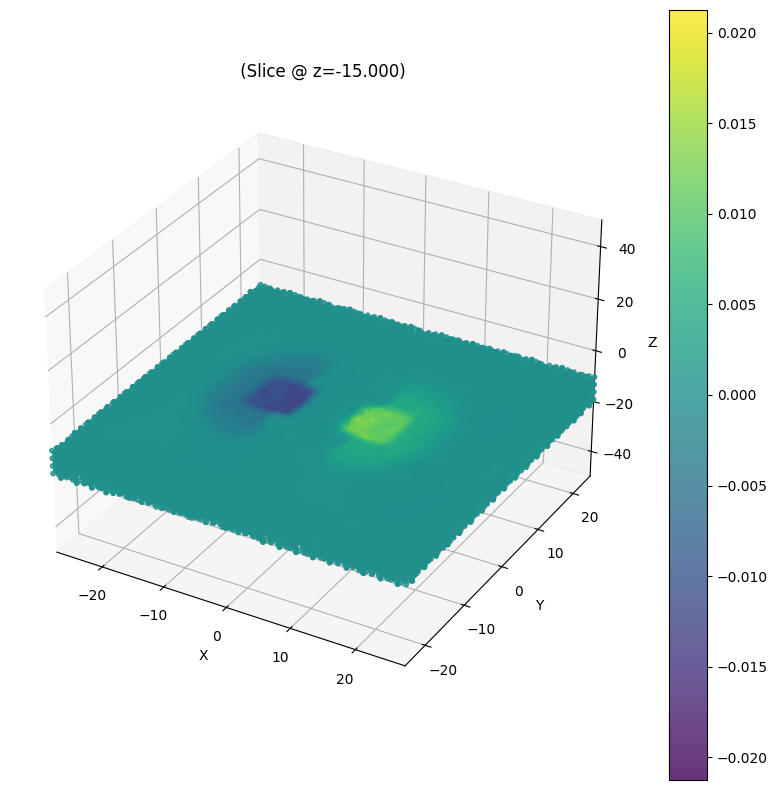

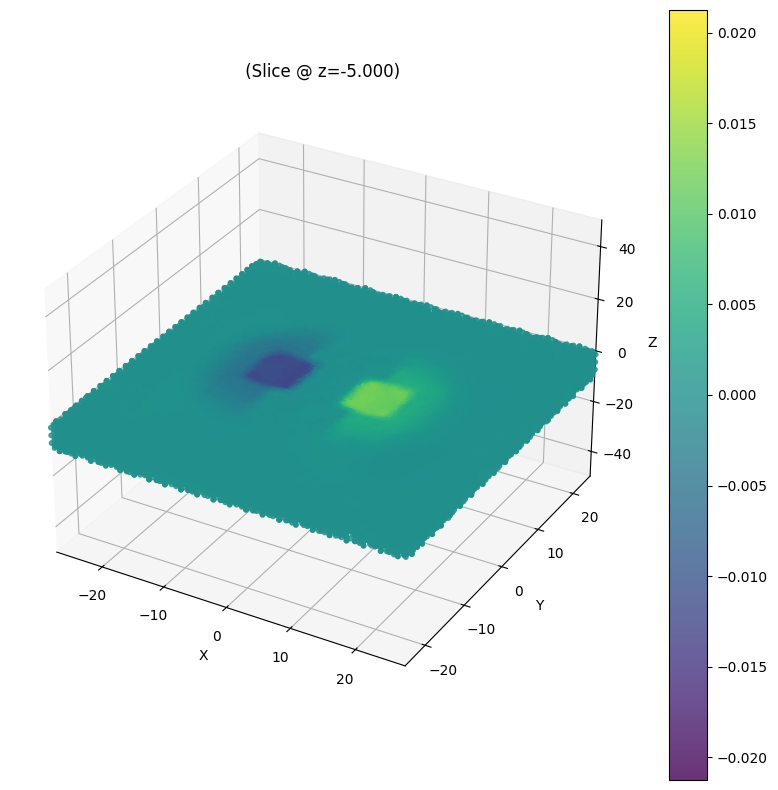

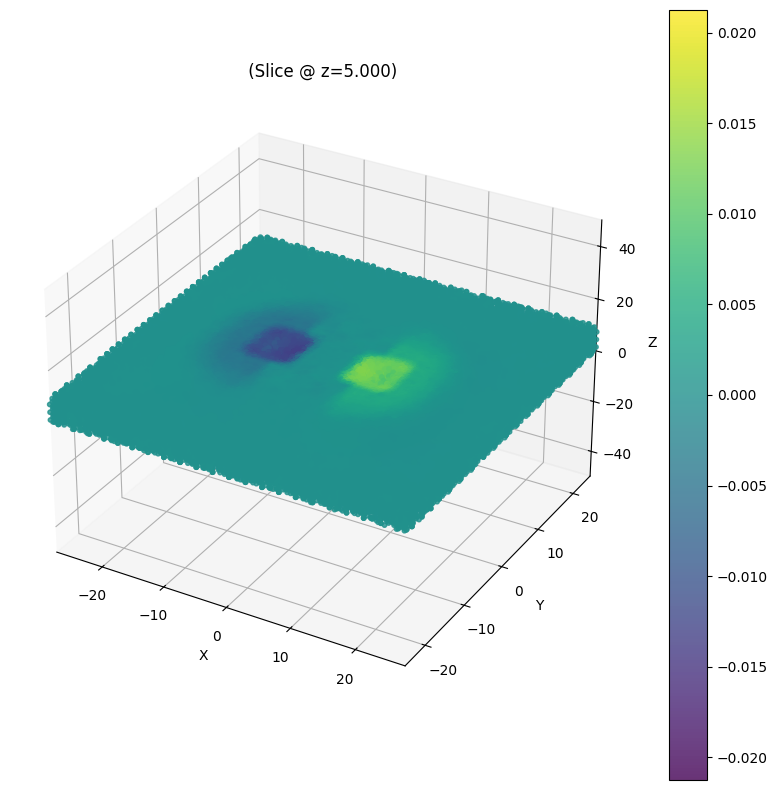

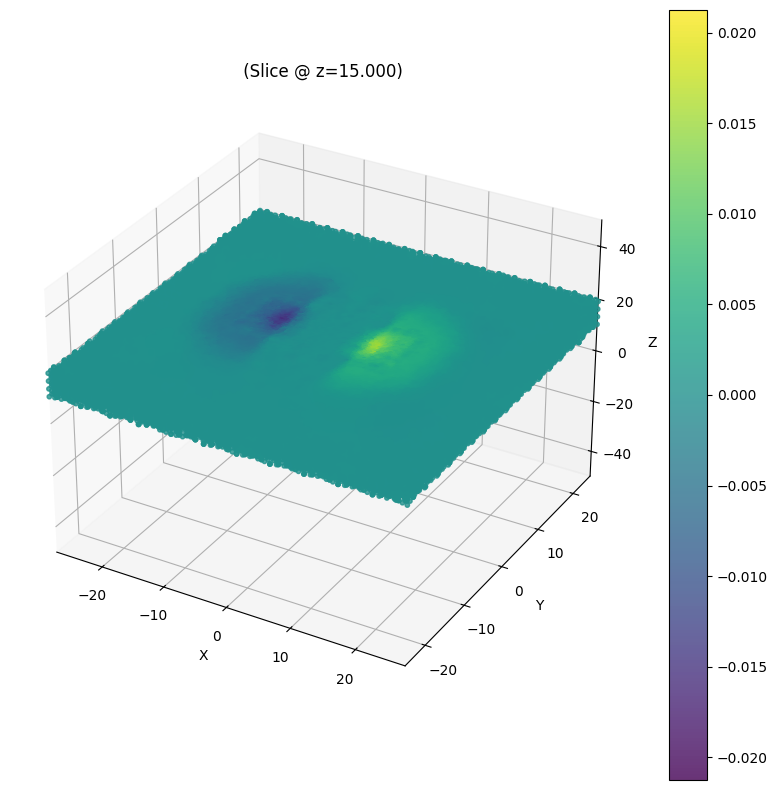

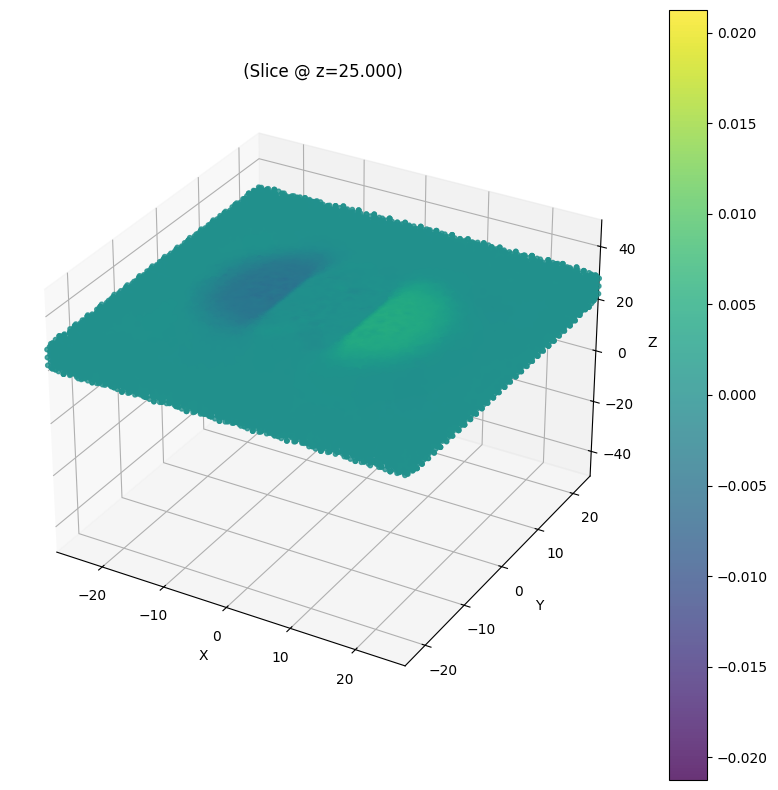

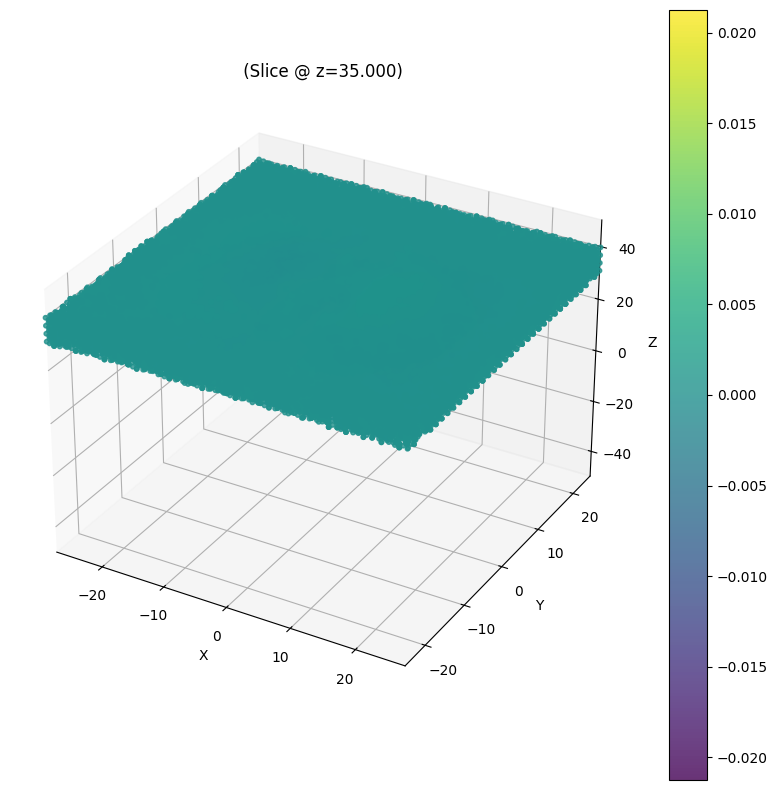

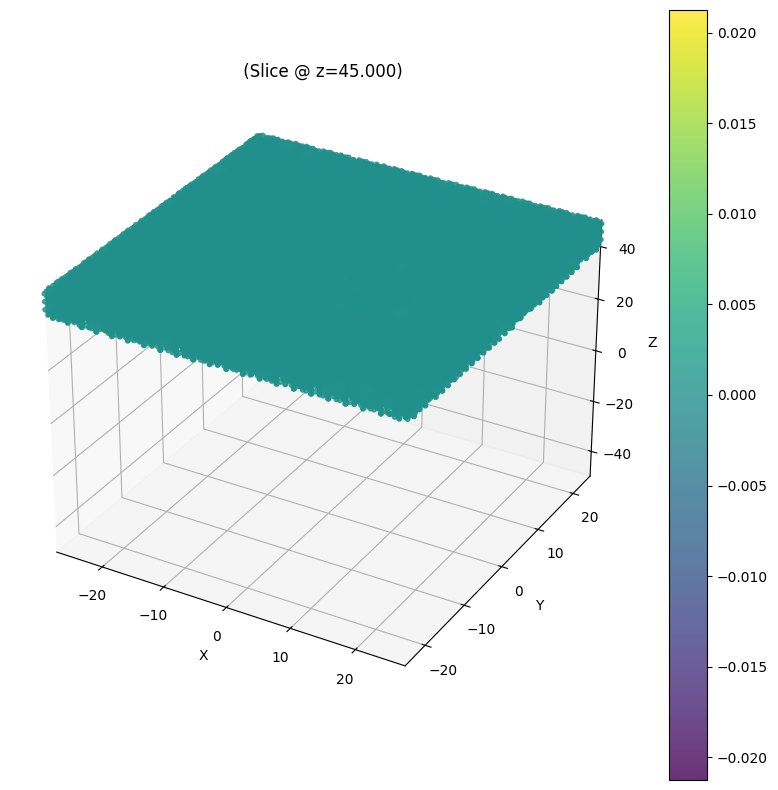

: 

In [ ]:
femsystem.plot_n_slices_interior(u_odd_interior,n_slices=10)

## Plot the Even Mode, in Slices

In [ ]:
femsystem.plot_n_slices_interior(u_even_interior,n_slices=10)

## Plot the Geometry, in Slices

In [ ]:
femsystem.plot_n_slices_interior(theta_at_interior,n_slices=10)